# Exploratory Data Analysis (EDA): The Complete Guide

## What is EDA?
**Exploratory Data Analysis (EDA)** is the process of **visually and statistically examining data** to understand its structure, patterns, anomalies, and relationships **before** building models.

EDA was formalized by **John Tukey** in his 1977 book *"Exploratory Data Analysis"*.

### Why EDA Matters
- Understand **what the data contains**
- Find **missing values, outliers, errors**
- Discover **relationships** between variables
- Guide **feature engineering** decisions
- Validate **assumptions** before modeling
- Prevent **garbage in, garbage out**

### EDA Workflow
```
1. Load & Inspect Data
2. Data Quality Assessment (missing, duplicates, types)
3. Univariate Analysis (each variable alone)
4. Bivariate Analysis (pairs of variables)
5. Multivariate Analysis (multiple variables)
6. Correlation Analysis
7. Automated Profiling
8. Insights & Next Steps
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# We'll use the Titanic dataset as our running example
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
try:
    df = pd.read_csv(url)
except:
    # Fallback: create synthetic titanic-like data
    np.random.seed(42)
    n = 891
    df = pd.DataFrame({
        'PassengerId': range(1, n+1),
        'Survived': np.random.choice([0, 1], n, p=[0.62, 0.38]),
        'Pclass': np.random.choice([1, 2, 3], n, p=[0.24, 0.21, 0.55]),
        'Name': [f'Passenger_{i}' for i in range(n)],
        'Sex': np.random.choice(['male', 'female'], n, p=[0.65, 0.35]),
        'Age': np.where(np.random.rand(n) < 0.2, np.nan,
                        np.clip(np.random.normal(30, 14, n), 0.5, 80)),
        'SibSp': np.random.choice([0,1,2,3,4], n, p=[0.68,0.23,0.06,0.02,0.01]),
        'Parch': np.random.choice([0,1,2,3], n, p=[0.76,0.13,0.09,0.02]),
        'Fare': np.where(np.random.rand(n) < 0.01, np.nan,
                         np.abs(np.random.exponential(32, n))),
        'Embarked': np.where(np.random.rand(n) < 0.02, np.nan,
                             np.random.choice(['S','C','Q'], n, p=[0.72,0.19,0.09]))
    })

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')

Dataset loaded: 891 rows × 12 columns


## Step 1: Load and Inspect

In [2]:
print('=== FIRST 5 ROWS ===')
print(df.head())
print('\n=== LAST 5 ROWS ===')
print(df.tail())
print('\n=== RANDOM SAMPLE ===')
print(df.sample(5, random_state=42))

=== FIRST 5 ROWS ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.050

In [3]:
print('=== SHAPE ===')
print(f'{df.shape[0]} rows, {df.shape[1]} columns')

print('\n=== DTYPES ===')
print(df.dtypes)

print('\n=== INFO ===')
df.info()

print('\n=== STATISTICAL SUMMARY ===')
print(df.describe(include='all'))

=== SHAPE ===
891 rows, 12 columns

=== DTYPES ===
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  

## Step 2: Data Quality Assessment

Missing Values:
          count    percent
Cabin       687  77.104377
Age         177  19.865320
Embarked      2   0.224467


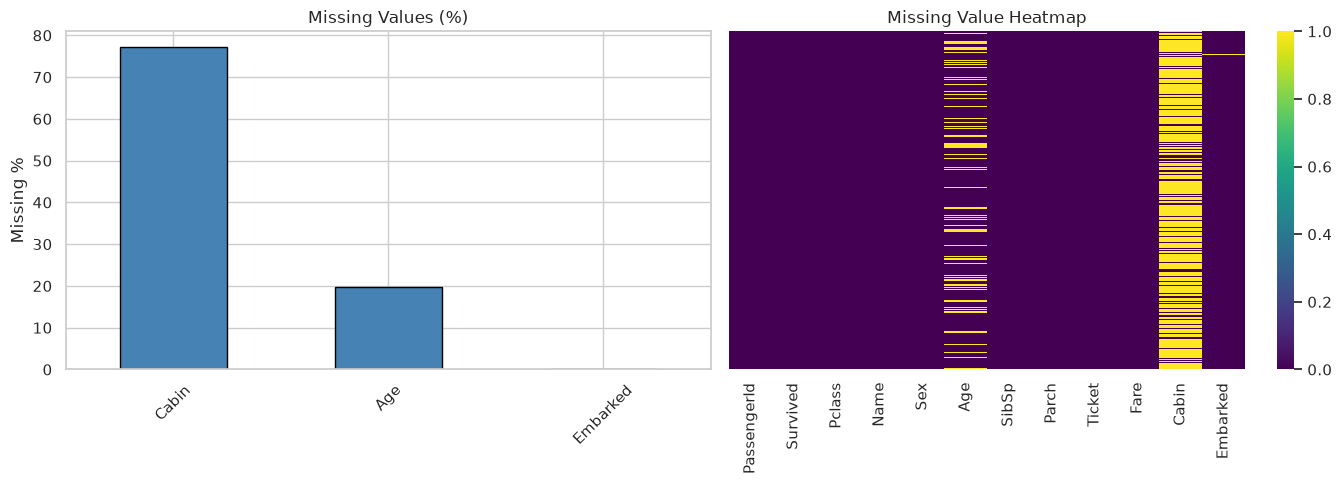

In [4]:
# Missing values analysis
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100
}).sort_values('percent', ascending=False)
missing = missing[missing['count'] > 0]
print('Missing Values:')
print(missing)

# Visualize missing values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing['percent'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Missing Values (%)')
axes[0].set_ylabel('Missing %')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)

# Heatmap of missingness
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[1])
axes[1].set_title('Missing Value Heatmap')

plt.tight_layout()
plt.savefig('/tmp/eda_missing.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Unique PassengerIds: {df["PassengerId"].nunique()}')

# Data types
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'\nNumeric columns: {numeric_cols}')
print(f'Categorical columns: {cat_cols}')

# Unique value counts for categoricals
print('\nCardinality of categorical columns:')
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values → {df[col].value_counts().head(3).to_dict()}')

Duplicate rows: 0
Unique PassengerIds: 891

Numeric columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Cardinality of categorical columns:
  Name: 891 unique values → {'Braund, Mr. Owen Harris': 1, 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)': 1, 'Heikkinen, Miss. Laina': 1}
  Sex: 2 unique values → {'male': 577, 'female': 314}
  Ticket: 681 unique values → {'347082': 7, '1601': 7, 'CA. 2343': 7}
  Cabin: 147 unique values → {'G6': 4, 'C23 C25 C27': 4, 'B96 B98': 4}
  Embarked: 3 unique values → {'S': 644, 'C': 168, 'Q': 77}


## Step 3: Univariate Analysis

Age: mean=29.70, median=28.00, std=14.53, skew=0.39, kurtosis=0.18
Fare: mean=32.20, median=14.45, std=49.69, skew=4.79, kurtosis=33.40
SibSp: mean=0.52, median=0.00, std=1.10, skew=3.70, kurtosis=17.88


Parch: mean=0.38, median=0.00, std=0.81, skew=2.75, kurtosis=9.78


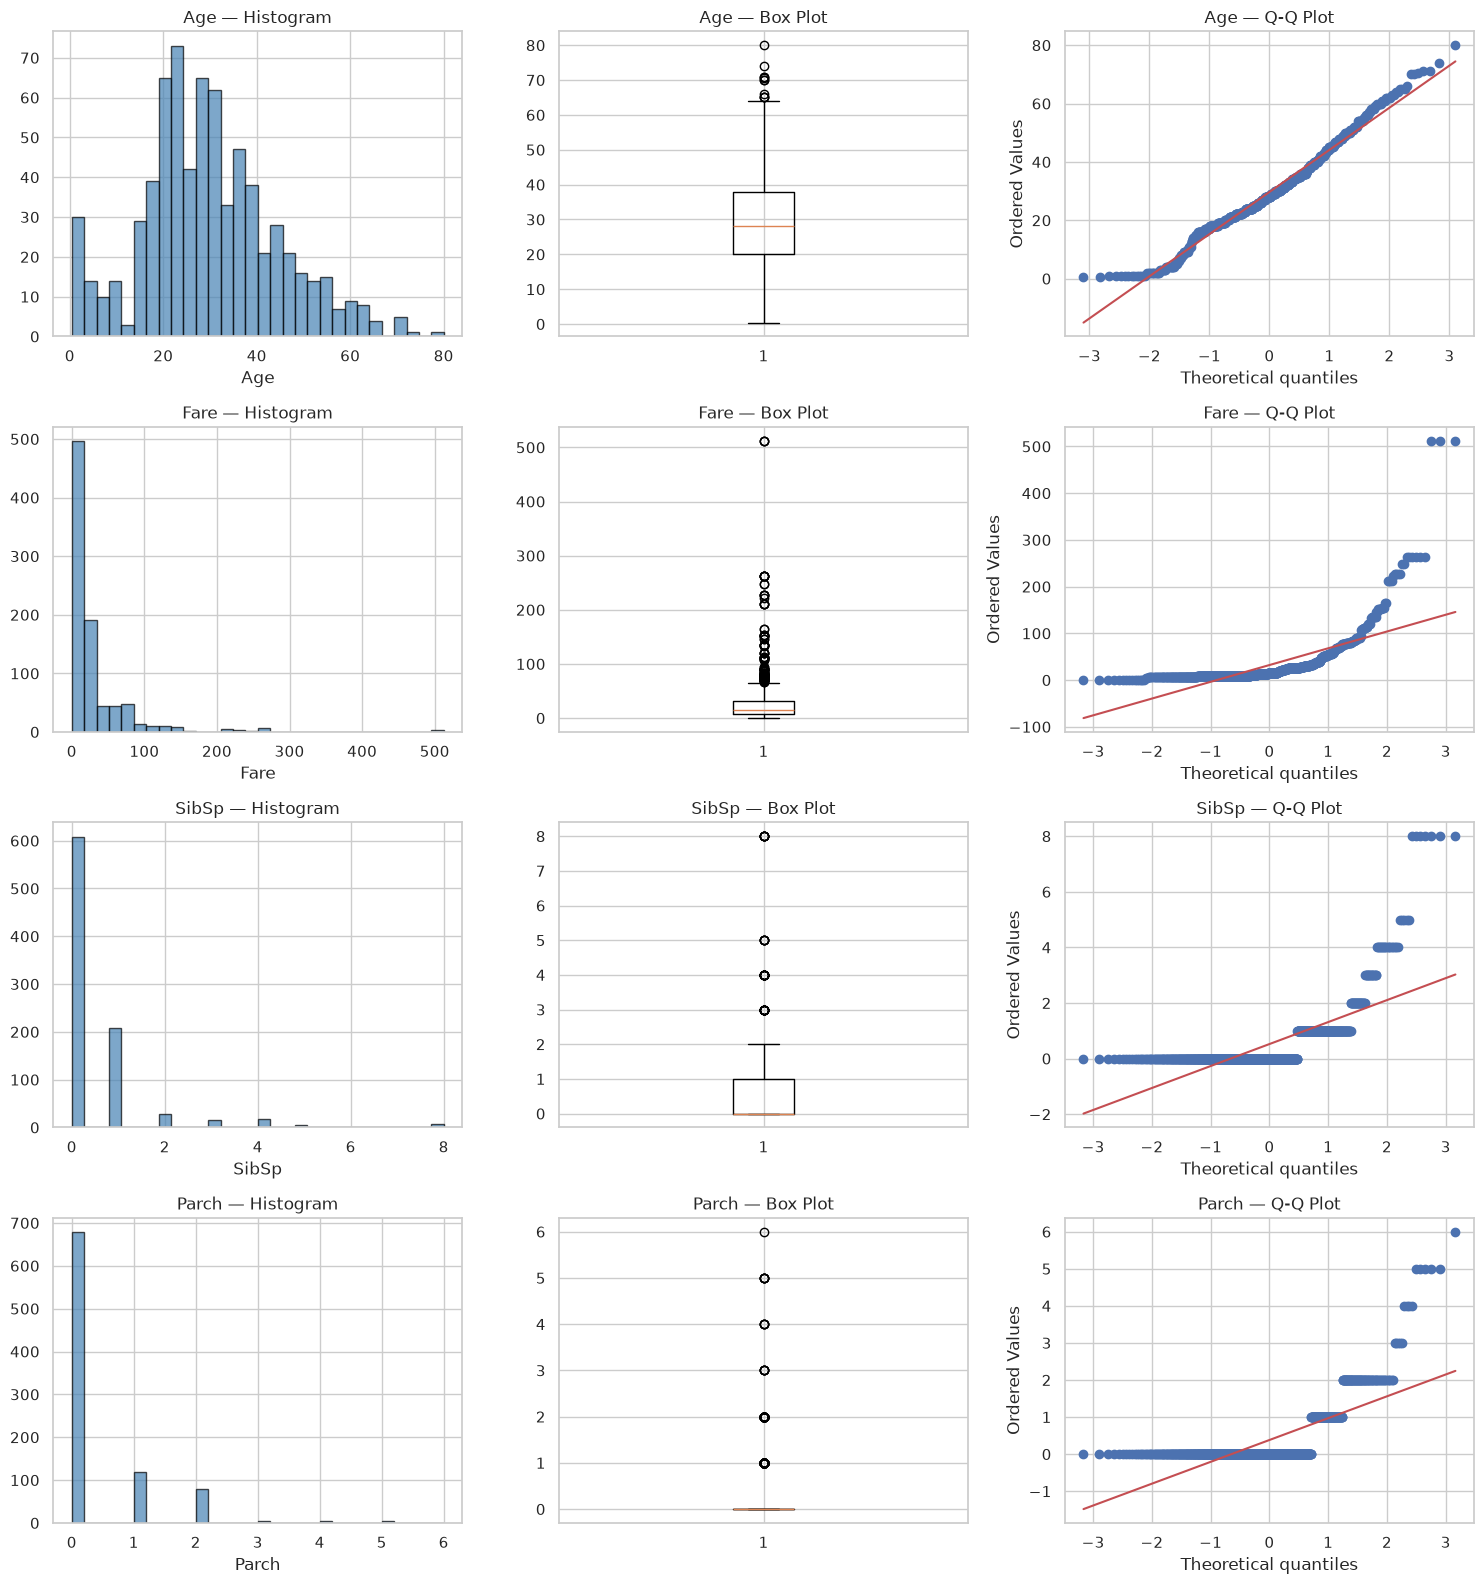

In [6]:
# Numerical variables
num_cols = ['Age', 'Fare', 'SibSp', 'Parch'] if 'Age' in df.columns else \
           df.select_dtypes(include='number').columns[:4].tolist()

fig, axes = plt.subplots(len(num_cols), 3, figsize=(15, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    col_data = df[col].dropna()

    # Histogram with KDE
    axes[i, 0].hist(col_data, bins=30, edgecolor='black', color='steelblue', alpha=0.7)
    axes[i, 0].set_title(f'{col} Histogram')
    axes[i, 0].set_xlabel(col)

    # Box plot
    axes[i, 1].boxplot(col_data, vert=True)
    axes[i, 1].set_title(f'{col} Box Plot')

    # Q-Q plot (normality check)
    stats.probplot(col_data, dist='norm', plot=axes[i, 2])
    axes[i, 2].set_title(f'{col} Q-Q Plot')

    # Print stats
    print(f'{col}: mean={col_data.mean():.2f}, median={col_data.median():.2f}, '
          f'std={col_data.std():.2f}, skew={col_data.skew():.2f}, '
          f'kurtosis={col_data.kurt():.2f}')

plt.tight_layout()
plt.savefig('/tmp/eda_univariate_num.png', dpi=150, bbox_inches='tight')
plt.show()

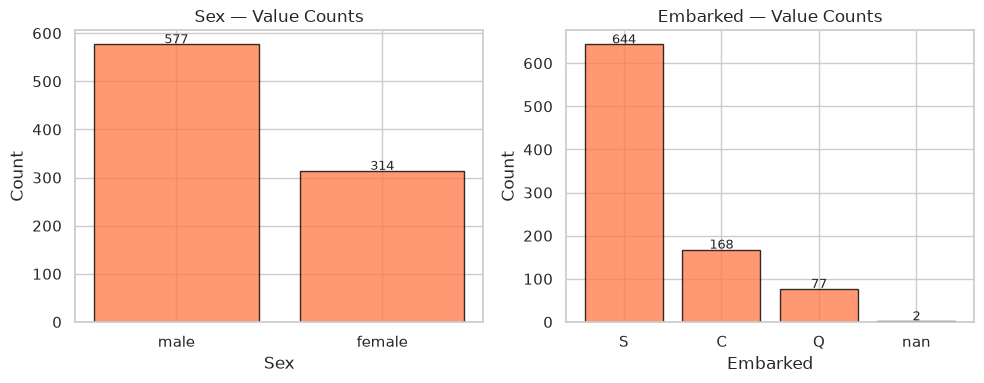

In [7]:
# Categorical variables
cat_cols_plot = [c for c in cat_cols if df[c].nunique() <= 10][:4]
if not cat_cols_plot and 'Pclass' in df.columns:
    cat_cols_plot = ['Survived', 'Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(5 * len(cat_cols_plot), 4))
if len(cat_cols_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols_plot):
    vc = df[col].value_counts(dropna=False)
    ax.bar([str(x) for x in vc.index], vc.values, edgecolor='black', color='coral', alpha=0.8)
    ax.set_title(f'{col} Value Counts')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    for j, v in enumerate(vc.values):
        ax.text(j, v + 2, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/tmp/eda_univariate_cat.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Bivariate Analysis

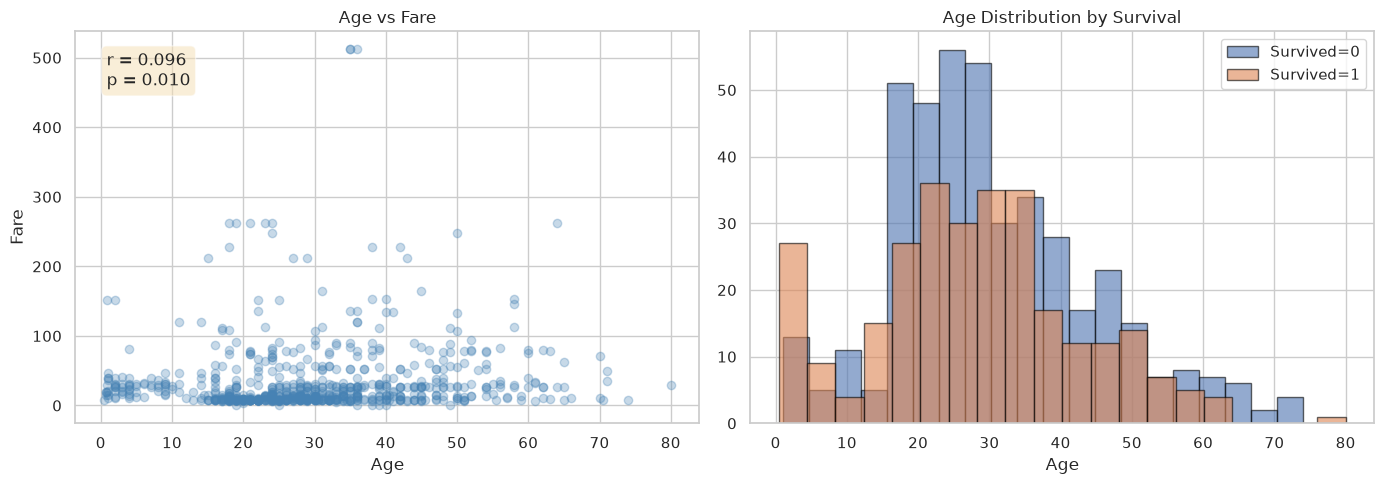

In [8]:
# Numerical vs Numerical
if 'Age' in df.columns and 'Fare' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Scatter plot
    axes[0].scatter(df['Age'], df['Fare'], alpha=0.3, color='steelblue')
    axes[0].set_title('Age vs Fare')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Fare')

    # Add correlation info
    valid = df[['Age', 'Fare']].dropna()
    r, p = stats.pearsonr(valid['Age'], valid['Fare'])
    axes[0].text(0.05, 0.95, f'r = {r:.3f}\np = {p:.3f}',
                 transform=axes[0].transAxes, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Numerical vs Categorical (target)
    for val in df['Survived'].unique() if 'Survived' in df.columns else []:
        subset = df[df['Survived'] == val]['Age'].dropna()
        axes[1].hist(subset, bins=20, alpha=0.6,
                    label=f'Survived={val}', edgecolor='black')
    axes[1].set_title('Age Distribution by Survival')
    axes[1].set_xlabel('Age')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('/tmp/eda_bivariate.png', dpi=150, bbox_inches='tight')
    plt.show()

Survival rate by Sex (%):
Survived          0          1
Sex                           
female    25.796178  74.203822
male      81.109185  18.890815


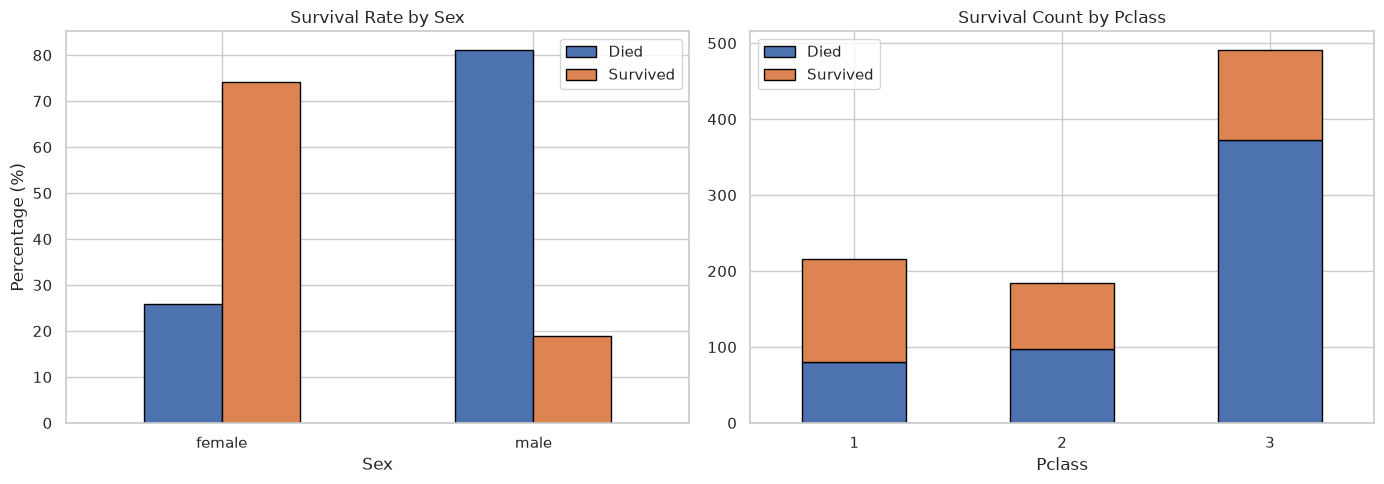

In [9]:
# Categorical vs Categorical
if 'Sex' in df.columns and 'Survived' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Cross-tabulation
    crosstab = pd.crosstab(df['Sex'], df['Survived'], normalize='index') * 100
    print('Survival rate by Sex (%):')
    print(crosstab)

    crosstab.plot(kind='bar', ax=axes[0], edgecolor='black')
    axes[0].set_title('Survival Rate by Sex')
    axes[0].set_ylabel('Percentage (%)')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
    axes[0].legend(['Died', 'Survived'])

    # Stacked bar
    pd.crosstab(df['Pclass'], df['Survived']).plot(kind='bar', stacked=True, ax=axes[1], edgecolor='black')
    axes[1].set_title('Survival Count by Pclass')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    axes[1].legend(['Died', 'Survived'])

    plt.tight_layout()
    plt.savefig('/tmp/eda_bivariate_cat.png', dpi=150, bbox_inches='tight')
    plt.show()

## Step 5: Multivariate Analysis

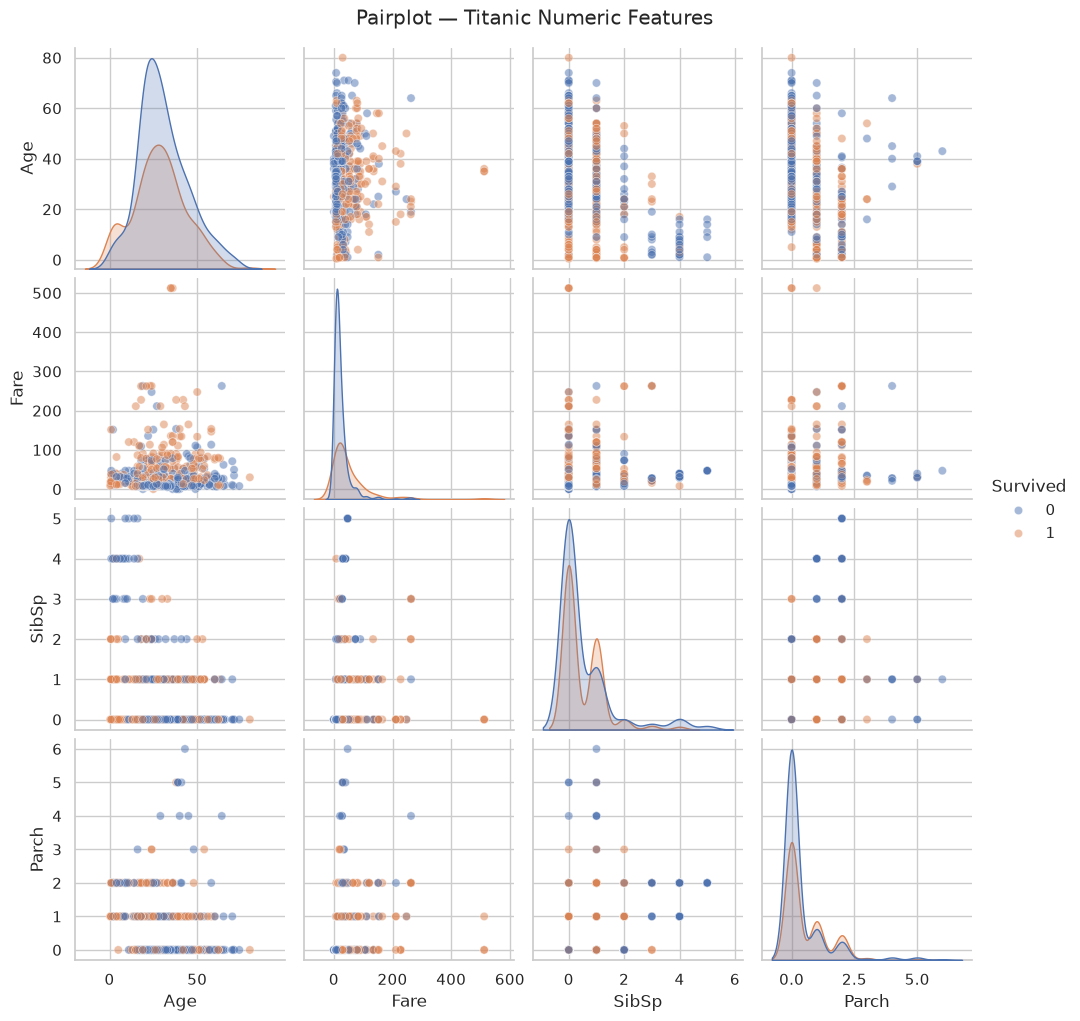

In [10]:
# Pairplot for numeric features
num_subset = df[['Age', 'Fare', 'SibSp', 'Parch']].copy() if 'Age' in df.columns else \
             df.select_dtypes(include='number').iloc[:, :4]

if 'Survived' in df.columns:
    num_subset['Survived'] = df['Survived'].astype(str)
    g = sns.pairplot(num_subset.dropna(), hue='Survived', diag_kind='kde',
                     plot_kws={'alpha': 0.5}, height=2.5)
    g.fig.suptitle('Pairplot Titanic Numeric Features', y=1.02)
    plt.savefig('/tmp/eda_pairplot.png', dpi=120, bbox_inches='tight')
    plt.show()

## Step 6: Correlation Analysis

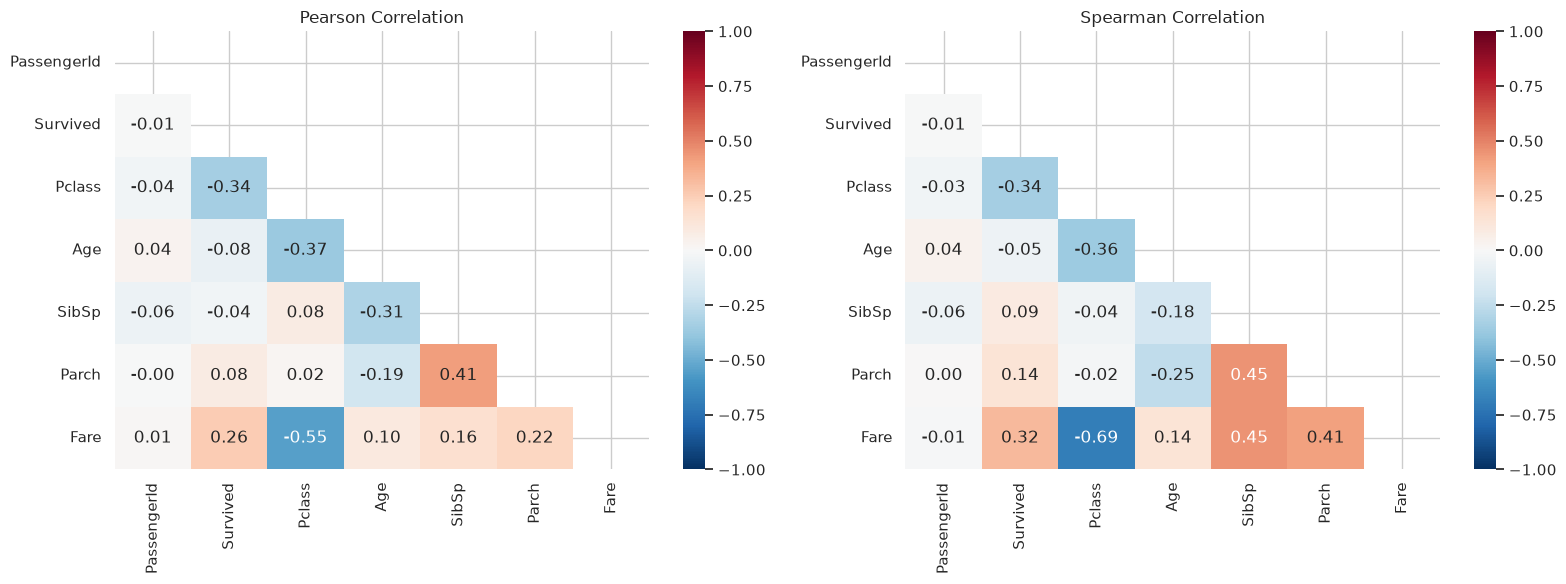

Correlations with Survived:
Pclass        -0.338481
Fare           0.257307
Parch          0.081629
Age           -0.077221
SibSp         -0.035322
PassengerId   -0.005007
Name: Survived, dtype: float64


In [11]:
# Pearson correlation (linear relationships)
num_df = df.select_dtypes(include='number')
corr_pearson = num_df.corr(method='pearson')

# Spearman correlation (monotonic relationships)
corr_spearman = num_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Pearson Correlation')

sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Spearman Correlation')

plt.tight_layout()
plt.savefig('/tmp/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
if 'Survived' in num_df.columns:
    target_corr = corr_pearson['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
    print('Correlations with Survived:')
    print(target_corr)

## Step 7: Automated Profiling

In [12]:
# ydata-profiling (formerly pandas-profiling) generates full HTML report
# pip install ydata-profiling
#
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title='Titanic EDA Report', explorative=True)
# profile.to_file('titanic_report.html')  # saves interactive HTML
# profile.to_notebook_iframe()            # shows inline in Jupyter

# sweetviz beautiful EDA reports
# pip install sweetviz
#
# import sweetviz as sv
# report = sv.analyze(df, target_feat='Survived')
# report.show_html('sweetviz_report.html')

# dtale interactive dashboard
# pip install dtale
#
# import dtale
# d = dtale.show(df)
# d.open_browser()

# Manual summary function
def quick_eda_summary(dataframe):
    print('=== QUICK EDA SUMMARY ===')
    print(f'Shape: {dataframe.shape}')
    print(f'Memory usage: {dataframe.memory_usage(deep=True).sum() / 1024:.1f} KB')
    print(f'Duplicate rows: {dataframe.duplicated().sum()}')
    print(f'\nMissing values:')
    print(dataframe.isnull().sum()[dataframe.isnull().sum() > 0])
    print(f'\nNumeric summary:')
    print(dataframe.describe())
    print(f'\nCategorical columns:')
    for col in dataframe.select_dtypes(include='object').columns:
        print(f'  {col}: {dataframe[col].nunique()} unique {dataframe[col].value_counts().head(3).to_dict()}')

quick_eda_summary(df)

=== QUICK EDA SUMMARY ===
Shape: (891, 12)
Memory usage: 285.6 KB
Duplicate rows: 0

Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64

Numeric summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400

## Additional Learning Resources

### Tutorials and Guides
- **Kaggle EDA Tutorial**: https://www.kaggle.com/learn/data-visualization
- **Towards Data Science EDA Guide**: https://towardsdatascience.com/exploratory-data-analysis-8fc1cb20fd15
- **Titanic EDA (Kaggle)**: https://www.kaggle.com/code/startupsci/titanic-data-science-solutions

### Tools Documentation
- **ydata-profiling**: https://docs.profiling.ydata.ai/
- **Sweetviz**: https://github.com/fbdesignpro/sweetviz
- **D-Tale**: https://github.com/man-group/dtale
- **Lux (intelligent viz)**: https://github.com/lux-org/lux

### Books
- **Exploratory Data Analysis** John Tukey (1977): The original EDA book
- **Python for Data Analysis** Wes McKinney: https://wesmckinney.com/book/
- **Storytelling with Data** Cole Nussbaumer Knaflic: https://www.storytellingwithdata.com/

### Videos
- **EDA with Python** Ken Jee: https://www.youtube.com/watch?v=xi0vhXFPegw
- **Kaggle EDA Walkthrough**: https://www.youtube.com/watch?v=fmBgTitxHMs